<a href="https://colab.research.google.com/github/n4b1lAh/project/blob/main/x_ray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
!pip install -q kaggle

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
!ls "/content/drive/MyDrive/Colab"


archive.zip  roverDataset.zip


In [52]:
import zipfile
import os

# Correct file path to your zip file
zip_path = '/content/drive/MyDrive/Colab/archive.zip'

# Destination folder for extracted files
extract_to = '/content/dataset/'

# Ensure the destination folder exists
os.makedirs(extract_to, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Dataset extracted to {extract_to}")


Dataset extracted to /content/dataset/


In [53]:
import os

dataset_path = '/content/dataset'
print(f"Contents of {dataset_path}:")
print(os.listdir(dataset_path))


Contents of /content/dataset:
['chest_xray']


In [54]:
train_dir = '/content/dataset/chest_xray/train'
val_dir = '/content/dataset/chest_xray/val'
test_dir = '/content/dataset/chest_xray/test'

# Define the labels
labels = ['NORMAL', 'PNEUMONIA'] # Assuming these are the folder names within train, test and val



In [55]:
# Function to count files in each subdirectory
def count_files(dir_path):
    for category in os.listdir(dir_path):
        category_path = os.path.join(dir_path, category)
        num_files = len(os.listdir(category_path))
        print(f"{category}: {num_files} files")

# Count files in train, validation, and test sets

print('Train Set: \n' + '='*50)
count_files(train_dir)

print('\nValidation Set: \n' + '='*50)
count_files(val_dir)

print('\nTest Set: \n' + '='*50)
count_files(test_dir)


Train Set: 
NORMAL: 1341 files
PNEUMONIA: 3875 files

Validation Set: 
NORMAL: 8 files
PNEUMONIA: 8 files

Test Set: 
NORMAL: 234 files
PNEUMONIA: 390 files


In [56]:
def get_file_sizes(directory):
    file_sizes = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            size = os.path.getsize(file_path) / 1024 #bytes to KB
            file_sizes.append({'file': file_path, 'size_kb': round(size,3)})
    return file_sizes

In [57]:
get_file_sizes(train_dir)[:5]

[{'file': '/content/dataset/chest_xray/train/NORMAL/NORMAL2-IM-1258-0001-0002.jpeg',
  'size_kb': 633.472},
 {'file': '/content/dataset/chest_xray/train/NORMAL/IM-0628-0001.jpeg',
  'size_kb': 758.404},
 {'file': '/content/dataset/chest_xray/train/NORMAL/IM-0685-0001.jpeg',
  'size_kb': 429.708},
 {'file': '/content/dataset/chest_xray/train/NORMAL/NORMAL2-IM-0384-0001.jpeg',
  'size_kb': 320.653},
 {'file': '/content/dataset/chest_xray/train/NORMAL/IM-0275-0001.jpeg',
  'size_kb': 611.535}]

In [58]:
def get_file_sizes(directory):
    file_sizes = []

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            size = os.path.getsize(file_path) / 1024 #bytes to KB
            file_sizes.append({'file': file_path, 'size_kb': round(size,3)})
    return file_sizes

def create_dataframe(path=None, labels=None):
    data = []
    for label in labels:
        category_path = os.path.join(path, label)
        file_sizes = get_file_sizes(category_path)
        data.extend(file_sizes)

    import pandas as pd #Import pandas inside function to avoid import errors
    df = pd.DataFrame(data)
    return df

In [59]:
train_df = create_dataframe(train_dir, labels)
test_df = create_dataframe(test_dir, labels)
val_df = create_dataframe(val_dir, labels)

print('shape of train_dir',train_df.shape)
print('shape of test_dir',test_df.shape)
print('shape of val_dir',val_df.shape)

shape of train_dir (5216, 2)
shape of test_dir (624, 2)
shape of val_dir (16, 2)


In [60]:
train_df.head(3)

,file,size_kb
0,/content/dataset/chest_xray/train/NORMAL/NORMA...,633.472
1,/content/dataset/chest_xray/train/NORMAL/IM-06...,758.404
2,/content/dataset/chest_xray/train/NORMAL/IM-06...,429.708


In [61]:
def extract_label(file_path):
    if 'PNEUMONIA' in file_path:
        return 'pneumonia'
    elif 'NORMAL' in file_path:
        return 'normal'
    else:
        return 'unknown'

dict_dir_df = {'train': train_df,
               'val': val_df,
               'test': test_df}

In [62]:
for df in dict_dir_df.values():
    df['label'] = df['file'].apply(extract_label)

In [63]:
train_df.sample(3)

,file,size_kb,label
1212,/content/dataset/chest_xray/train/NORMAL/IM-05...,349.672,normal
1908,/content/dataset/chest_xray/train/PNEUMONIA/pe...,76.557,pneumonia
4320,/content/dataset/chest_xray/train/PNEUMONIA/pe...,56.706,pneumonia


In [64]:
def get_image_dimensions(file_path):
    try:
        with Image.open(file_path) as img:
            return img.size
    except Exception as e:
        print(f"Error reading image {file_path}: {e}")
        return (0, 0)

In [65]:
for name, df in dict_dir_df.items():
    df['dimensions'] = df['file'].apply(get_image_dimensions)

Streaming output truncated to the last 5000 lines.
Error reading image /content/dataset/chest_xray/train/NORMAL/NORMAL2-IM-0671-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train/NORMAL/NORMAL2-IM-0595-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train/NORMAL/IM-0515-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train/NORMAL/NORMAL2-IM-1275-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train/NORMAL/IM-0268-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train/NORMAL/IM-0372-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train/NORMAL/NORMAL2-IM-0653-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train/NORMAL/IM-0363-0001.jpeg: name 'Image' is not defined
Error reading image /content/dataset/chest_xray/train

In [66]:
for name, df in dict_dir_df.items():
    filtered_dir = df[df['dimensions'].apply(lambda x: len(x) >= 3)]
    print(f'{name}:',filtered_dir.shape[0])

train: 0
val: 0
test: 0


In [67]:
print('shape of train_dir',train_df.shape)
print('shape of test_dir',test_df.shape)
print('shape of val_dir',val_df.shape)

shape of train_dir (5216, 4)
shape of test_dir (624, 4)
shape of val_dir (16, 4)


In [68]:
import pandas as pd # Add this line at the beginning of the cell

merged_df = pd.concat([train_df, val_df,test_df], ignore_index=True)
merged_df.shape

(5856, 4)

In [69]:
!pip install scikit-learn # install scikit-learn if you haven't already
from sklearn.model_selection import train_test_split # import the function

train_df, test_df_full = train_test_split(merged_df, test_size=0.3,
                                    stratify = merged_df['label'], random_state=42)

test_df, val_df = train_test_split(test_df_full, test_size=0.5,
                                    stratify = test_df_full['label'], random_state=42)

In [70]:
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)

(4099, 4)
(878, 4)
(879, 4)


In [71]:
def preprocess_image(file_path, label, channels=3):

    img = tf.io.read_file(file_path)


    img = tf.image.decode_jpeg(img, channels=channels)


    img = tf.image.resize(img, [224, 224])


    img = tf.cast(img, tf.float32) / 255.0


    label = tf.where(tf.math.equal(label, 'normal'), 0, 1)


    return img, label

In [72]:
def color_jitter(image, brightness_factor=0.01, contrast_factor=0.01, seed=None):
    image = tf.image.random_brightness(image, max_delta=0.1, seed=seed)
    image = tf.image.random_contrast(image, lower=1-contrast_factor, upper=1+contrast_factor, seed=seed)
    image = tf.image.random_saturation(image, lower=1-contrast_factor, upper=1+contrast_factor, seed=seed)
    image = tf.image.random_hue(image, max_delta=0.1, seed=seed)

    return image

In [73]:
def visualize(original, augmented):
  fig = plt.figure()
  plt.subplot(1,2,1)
  plt.title('Original image')
  plt.imshow(original)

  plt.subplot(1,2,2)
  plt.title('Augmented image')
  plt.imshow(augmented)

In [74]:
!pip install tensorflow #Install TensorFlow
import tensorflow as tf # Import TensorFlow library
!pip install matplotlib # Install matplotlib
import matplotlib.pyplot as plt # Import pyplot and alias it as plt

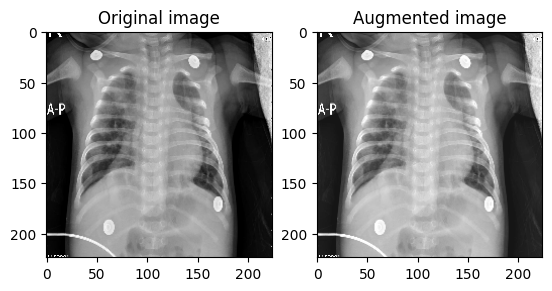

In [75]:
image_path = '/content/dataset/chest_xray/test/PNEUMONIA/person1610_virus_2793.jpeg' #Corrected the file path
img, label = preprocess_image(image_path,'pneumonia',channels=3)
color_jiter_test = color_jitter(img,seed=3)
visualize(img, color_jiter_test)

In [76]:
img.shape

TensorShape([224, 224, 3])

In [77]:
number = train_df.shape[0]
factors = []


for i in range(1, number + 1):
    if number % i == 0:
        factors.append(i)


print("factor to factor distribution", number, "is:", factors)

factor to factor distribution 4099 is: [1, 4099]


In [78]:
AUTOTUNE = tf.data.experimental.AUTOTUNE


batch_size = 32

In [79]:
def augment_train_image(img, label):

    #img = tf.image.random_flip_left_right(img)
    #img = tf.image.random_flip_up_down(img)
    img= color_jitter(img, seed=3)
    return img, label


def augment_val_image(img, label):

    return img, label

layers_augmentation = tf.keras.Sequential([
            #tf.keras.layers.RandomFlip("horizontal_and_vertical"),
            tf.keras.layers.RandomRotation(0.02),
            tf.keras.layers.RandomZoom(height_factor=(0.05, 0.1),width_factor=(0.05, 0.1)),
        ])

In [80]:
def prepare(ds, batch_size=32,shuffle=False, layers_aug=False, custom_aug=False):

    ds = ds.map(preprocess_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    ds = ds.cache()

    if shuffle:
        ds = ds.shuffle(buffer_size=1000)


    if custom_aug:
        ds = ds.map(augment_train_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)

    if layers_aug:
        ds = ds.map(lambda x, y: (layers_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [81]:
train_image_paths = train_df['file'].values
train_labels = train_df['label'].values

train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))

train_ds= prepare(train_dataset, batch_size, shuffle=False, custom_aug=True)


val_dataset = tf.data.Dataset.from_tensor_slices((val_df['file'].values, val_df['label'].values))
val_ds = prepare(val_dataset,batch_size, shuffle=False)

test_dataset = tf.data.Dataset.from_tensor_slices((test_df['file'].values, test_df['label'].values))
test_ds = prepare(test_dataset, batch_size, shuffle=False)

In [82]:
for images, labels in train_ds.take(1):
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch Size: {images.shape[0]}")
    print(f"Labels: {labels}")

Batch of images shape: (32, 224, 224, 3)
Batch Size: 32
Labels: [1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1]


In [83]:
for images, labels in train_ds.take(1):
    print(images[0,:,:,0])

tf.Tensor(
[[-0.02148986 -0.02148986 -0.02148986 ... -0.02148986 -0.02148986
  -0.02148986]
 [-0.02148986 -0.02148986 -0.02148986 ... -0.02030209 -0.02148986
  -0.02148986]
 [-0.02148986 -0.02148986 -0.02148986 ...  0.79101586 -0.00178763
  -0.02148986]
 ...
 [-0.02148986 -0.02148986 -0.02148986 ... -0.01643544 -0.02043521
  -0.02148986]
 [-0.02148986 -0.02148986 -0.02148986 ... -0.02148986 -0.02148986
  -0.02148986]
 [-0.02148986 -0.02148986 -0.02148986 ... -0.02148986 -0.02148986
  -0.02148986]], shape=(224, 224), dtype=float32)


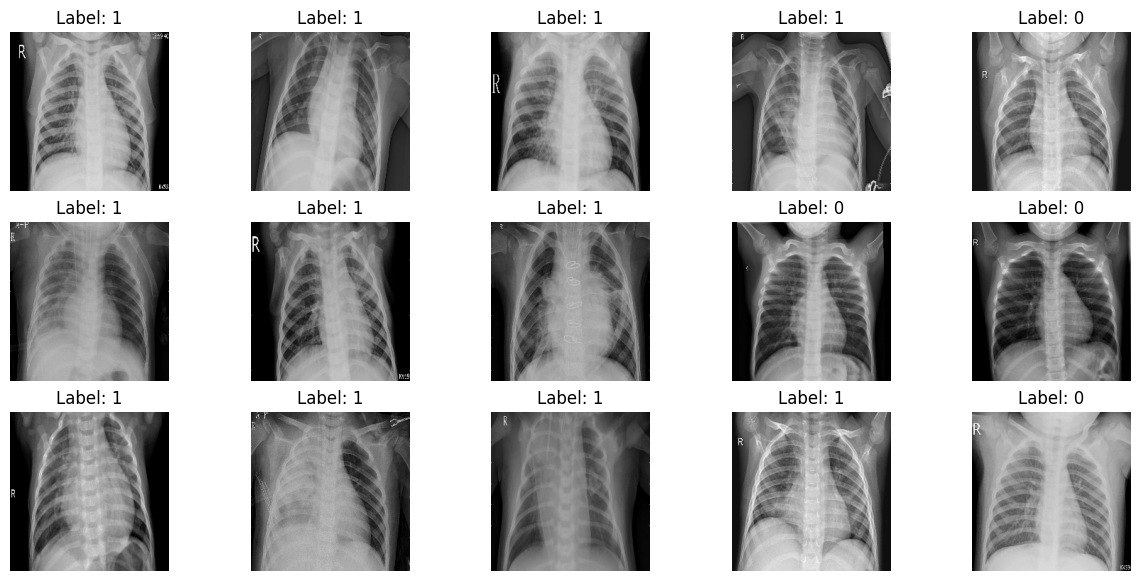

In [84]:
for images, labels in train_ds.take(1):

    plt.figure(figsize=(15, 7))
    for i in range(15):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[i])
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis('off')
    plt.show()

In [85]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D

In [86]:
#  model VGG16 pre-trained
from tensorflow.keras.layers import Flatten, Dense, Dropout # Import Flatten here
input_shape= (224, 224, 3)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
model_4 = tf.keras.Sequential()
model_4.add(base_model)
#model_4.add(GlobalAveragePooling2D())
model_4.add(Flatten())
model_4.add(Dense(198, activation='relu'))
model_4.add(Dense(128, activation='relu'))
model_4.add(Dropout(0.2))
model_4.add(Dense(1, activation='sigmoid'))

for layer in base_model.layers:
    layer.trainable = False

In [87]:
model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 198)                 │       4,967,622 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          25,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,707,911 (75.18 MB)

 Trainable params: 4,993,223 (19.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [88]:
#  learning rate
learning_rate = 0.01  # dafault 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
model_4.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [89]:
import os # Import the os module
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau # Import the necessary classes

checkpoint_filepath4 = '/tmp/checkpoint4.weights.h5'
checkpoint_dir4 = os.path.dirname(checkpoint_filepath4)

callbacks_1 = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ModelCheckpoint(filepath=checkpoint_filepath4, monitor='val_loss',mode='min',
                    save_weights_only=True, save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)
]

In [114]:
history_4= model_4.fit(train_ds, validation_data=val_ds,
            epochs=200,
            callbacks=callbacks_1, verbose=1)

Epoch 1/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 29s 219ms/step - accuracy: 0.9919 - loss: 0.0215 - val_accuracy: 0.9693 - val_loss: 0.0961 - learning_rate: 4.0000e-04
Epoch 2/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 26s 205ms/step - accuracy: 0.9934 - loss: 0.0219 - val_accuracy: 0.9727 - val_loss: 0.0939 - learning_rate: 4.0000e-04
Epoch 3/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 26s 202ms/step - accuracy: 0.9948 - loss: 0.0189 - val_accuracy: 0.9716 - val_loss: 0.0980 - learning_rate: 4.0000e-04
Epoch 4/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 42s 210ms/step - accuracy: 0.9934 - loss: 0.0159 - val_accuracy: 0.9727 - val_loss: 0.0956 - learning_rate: 4.0000e-04
Epoch 5/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 40s 207ms/step - accuracy: 0.9935 - loss: 0.0155 - val_accuracy: 0.9727 - val_loss: 0.0951 - learning_rate: 8.0000e-05
Epoch 6/200
129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 208ms/step - accuracy: 0.9961 - loss: 0.0134 - val_accuracy: 0.9738 - val_loss: 0.0940 - learning_rate: 8.0000e-05


In [115]:
import numpy as np # Import numpy for numerical operations

def plot_training_history(history_name=None, start_epoch=1):
    if history_name is None:
        raise ValueError("Parameter 'history_name' must be fill with objective (history).")

    train_loss = history_name.history['loss']
    val_loss = history_name.history['val_loss']
    train_acc = history_name.history['accuracy']
    val_acc = history_name.history['val_accuracy']
    range_epoch = np.arange(start_epoch, start_epoch + len(train_loss))

    # Get learning rates from the history object if available, otherwise create a list of initial learning rate
    #learning_rate = history_name.history.get('lr', [history_name.model.optimizer.lr.numpy()] * len(train_loss)) # The problem line
    learning_rate = history_name.history.get('lr', [history_name.model.optimizer.learning_rate.numpy()] * len(train_loss)) # Fixed: Use learning_rate

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range_epoch, train_loss, label='Training Loss', marker='o', color='red')
    plt.plot(range_epoch, val_loss, label='Validation Loss', marker='x', color='blue')
    plt.plot(range_epoch, learning_rate, label='learning_rate', marker='*', color='green')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.xticks(np.arange(start_epoch, start_epoch + len(train_loss), step=2))

    plt.subplot(1, 2, 2)
    plt.plot(range_epoch, train_acc, label='Training Accuracy', marker='o', color='red')
    plt.plot(range_epoch, val_acc, label='Validation Accuracy', marker='x', color='blue')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.xticks(range_epoch)
    plt.xticks(np.arange(start_epoch, start_epoch + len(train_loss), step=2))

    plt.show()

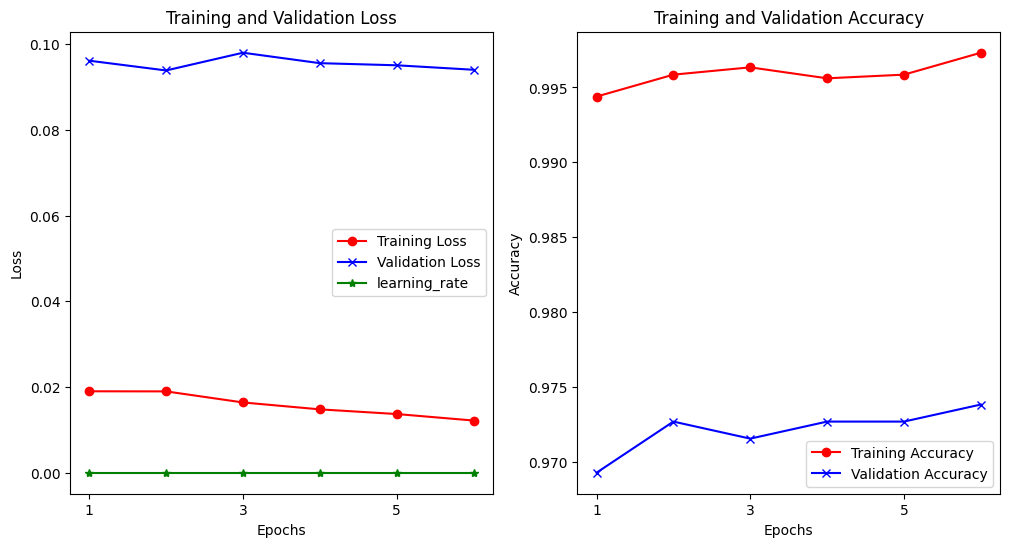

In [116]:
plot_training_history(history_name=history_4)

In [117]:
def evaluate(data=None, model=None):
    loss, acc = model.evaluate(data, verbose=2)
    print("Restored model, accuracy: {:5.2f}%".format(100 * acc))
    print("Restored model, loss: {:5.2f}%".format(100 * loss))

In [118]:
model_4.load_weights(checkpoint_filepath4)
evaluate(val_ds,model_4)

28/28 - 5s - 167ms/step - accuracy: 0.9727 - loss: 0.0936
Restored model, accuracy: 97.27%
Restored model, loss:  9.36%


In [119]:
evaluate(train_ds,model_4)

129/129 - 23s - 176ms/step - accuracy: 0.9937 - loss: 0.0178
Restored model, accuracy: 99.37%
Restored model, loss:  1.78%


In [120]:
evaluate(test_ds,model_4)

28/28 - 5s - 163ms/step - accuracy: 0.9647 - loss: 0.1311
Restored model, accuracy: 96.47%
Restored model, loss: 13.11%


In [121]:
model_4.save('model_4.keras')

In [128]:
tf.keras.backend.clear_session()

In [130]:
# Define function to make prediction
def predict_and_evaluate(model, dataset):
    y_true = []
    y_pred = []

    #  Iterate through the dataset to get the actual label and result prediction
    for image, label in dataset:
        predictions = model.predict(image,verbose=0)
        y_true.extend(label.numpy())
        y_pred.extend(np.round(predictions).flatten())

   # classification report
    report = classification_report(y_true, y_pred, target_names=['normal', 'pneumonia'])

    return report

In [131]:
def calculate_confusion_matrix(model, dataset):
    y_true = []  # Label yang sebenarnya
    y_pred = []  # Label hasil prediksi


    for image, label in dataset:
        predictions = model.predict(image,verbose=0)
        y_true.extend(label.numpy())
        y_pred.extend(np.round(predictions).flatten())

    #  confusion matrix
    conf_matrix = confusion_matrix(y_true, y_pred)

    #Plot confusion_matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


    tn, fp, fn, tp = conf_matrix.ravel()
    #tp = conf_matrix[1, 1]
    #p = conf_matrix[0, 1]
    #tn = conf_matrix[0, 0]
    #fn = conf_matrix[1, 0]

    return tp, fp, tn, fn

In [132]:
!pip install -q scikit-learn # Install scikit-learn if needed
from sklearn.metrics import classification_report # Import the function

# Define function to make prediction
def predict_and_evaluate(model, dataset):
    y_true = []
    y_pred = []

    #  Iterate through the dataset to get the actual label and result prediction
    for image, label in dataset:
        predictions = model.predict(image,verbose=0)
        y_true.extend(label.numpy())
        y_pred.extend(np.round(predictions).flatten())

   # classification report
    report = classification_report(y_true, y_pred, target_names=['normal', 'pneumonia'])

    return report

In [133]:
#Load model
loaded_model_4 = tf.keras.models.load_model('model_4.keras')
classification_report_result = predict_and_evaluate(loaded_model_4, test_ds)
#  classification report
print(classification_report_result)

              precision    recall  f1-score   support

      normal       0.96      0.91      0.93       237
   pneumonia       0.97      0.98      0.98       641

    accuracy                           0.96       878
   macro avg       0.96      0.95      0.95       878
weighted avg       0.96      0.96      0.96       878



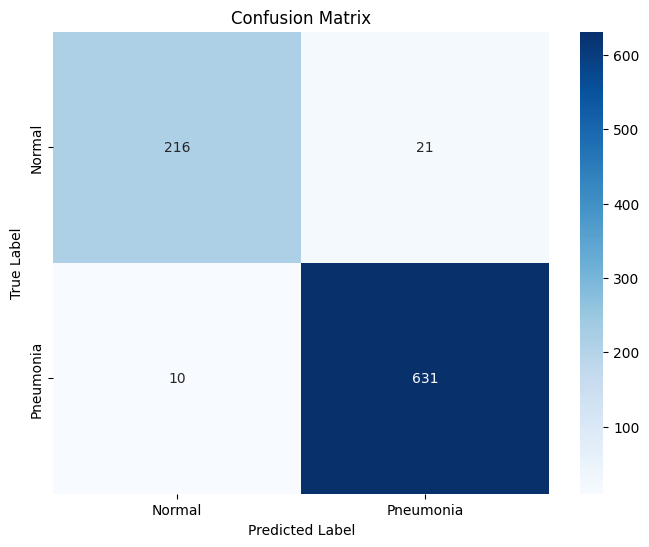

True Positive (TP): 631
False Positive (FP): 21
True Negative (TN): 216
False Negative (FN): 10


In [134]:
!pip install -q scikit-learn # Install scikit-learn if needed
import seaborn as sns # Import seaborn and alias it as sns
from sklearn.metrics import confusion_matrix # Import confusion_matrix

# Increasing confusion matrix by model loading and dataset testing
tp, fp, tn, fn = calculate_confusion_matrix(loaded_model_4, test_ds)
print("True Positive (TP):", tp)
print("False Positive (FP):", fp)
print("True Negative (TN):", tn)
print("False Negative (FN):", fn)

In [137]:
!pip install torch # Install PyTorch
import torch
loaded_model_4.save("/content/drive/MyDrive/chest_xray_model.keras")
print("✅ Model checkpoint saved.")

# To load the model later, you would use:
# loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/chest_xray_model.keras")

✅ Model checkpoint saved.
